<a href="https://colab.research.google.com/github/CS171-Semester-Project/traffic-sign-detection/blob/main/traffic_sign_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
from google.colab import userdata

In [2]:
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

##**DATA PREPARATION**

In [3]:
# Download the dataset
!kaggle datasets download -d pkdarabi/cardetection

# Unzip the downloaded dataset
!unzip -q cardetection.zip -d cardetection_dataset

Dataset URL: https://www.kaggle.com/datasets/pkdarabi/cardetection
License(s): Attribution 4.0 International (CC BY 4.0)
100% 99.8M/99.8M [00:05<00:00, 17.7MB/s]



In [4]:
for dirpath, dirnames, filenames in os.walk("cardetection_dataset/car/train"):
    print(f"Train data path: {dirpath}")
    print(f"Train data directories length: {len(dirnames)}")
    print(f"Train data filenames length: {len(filenames)}")

print()

for dirpath, dirnames, filenames in os.walk("cardetection_dataset/car/test"):
    print(f"Test data path: {dirpath}")
    print(f"Test data directories length: {len(dirnames)}")
    print(f"Test data filenames length: {len(filenames)}")

print()

for dirpath, dirnames, filenames in os.walk("cardetection_dataset/car/valid"):
    print(f"Validation data path: {dirpath}")
    print(f"Validation data directories length: {len(dirnames)}")
    print(f"Validation data filenames length: {len(filenames)}")

Train data path: cardetection_dataset/car/train
Train data directories length: 2
Train data filenames length: 0
Train data path: cardetection_dataset/car/train/labels
Train data directories length: 0
Train data filenames length: 3530
Train data path: cardetection_dataset/car/train/images
Train data directories length: 0
Train data filenames length: 3530

Test data path: cardetection_dataset/car/test
Test data directories length: 2
Test data filenames length: 0
Test data path: cardetection_dataset/car/test/labels
Test data directories length: 0
Test data filenames length: 638
Test data path: cardetection_dataset/car/test/images
Test data directories length: 0
Test data filenames length: 638

Validation data path: cardetection_dataset/car/valid
Validation data directories length: 2
Validation data filenames length: 0
Validation data path: cardetection_dataset/car/valid/labels
Validation data directories length: 0
Validation data filenames length: 801
Validation data path: cardetection_da

In [5]:
import yaml

yaml_path = "cardetection_dataset/car/data.yaml"

with open(yaml_path, "r") as f:
    data_info = yaml.safe_load(f)

In [6]:
# Getting all the class or label names
class_names = data_info.get('names', [])
print(f"Total Number of Classes: {len(class_names)}\n")

print("Class Names:")
for i, name in enumerate(class_names):
    print(f"{i}: {name}")

Total Number of Classes: 15

Class Names:
0: Green Light
1: Red Light
2: Speed Limit 10
3: Speed Limit 100
4: Speed Limit 110
5: Speed Limit 120
6: Speed Limit 20
7: Speed Limit 30
8: Speed Limit 40
9: Speed Limit 50
10: Speed Limit 60
11: Speed Limit 70
12: Speed Limit 80
13: Speed Limit 90
14: Stop


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import glob

In [8]:
train_images_dir = "cardetection_dataset/car/train/images"
train_labels_dir = "cardetection_dataset/car/train/labels"

if os.path.exists(train_images_dir) and os.path.exists(train_labels_dir):
    image_files = [f for f in os.listdir(train_images_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
    if image_files:
        random_image = random.choice(image_files)
        # Labels usually have the same base name with a .txt extension in YOLO format
        corresponding_label = os.path.splitext(random_image)[0] + '.txt'

        print(f"Image File: {random_image}")
        print(f"Label File: {corresponding_label}")

        # Verify if the label file actually exists
        if os.path.exists(os.path.join(train_labels_dir, corresponding_label)):
            print("Status: Corresponding label file exists!")
        else:
            print("Status: Corresponding label file is missing.")

Image File: FisheyeCamera_1_00041_png.rf.2393d85160cf4b4a7c6c7510a07797f2.jpg
Label File: FisheyeCamera_1_00041_png.rf.2393d85160cf4b4a7c6c7510a07797f2.txt
Status: Corresponding label file exists!


In [9]:
# Get all train images
view_train_img = glob.glob("cardetection_dataset/car/train/images/*.jpg")
if not view_train_img:
    view_train_img = glob.glob("cardetection_dataset/car/valid/images/*.jpg")

In [10]:
# Function to get labels for each image
def get_labels(img_path):
    label_path = img_path.replace("/images/", "/labels/").replace(".jpg", ".txt")
    found_classes = set()
    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            lines = f.readlines()
            for line in lines:
                parts = line.strip().split()
                if len(parts) >= 1:
                    class_id = int(parts[0])
                    if "data_info" in globals() and "names" in data_info:
                        class_name = data_info["names"][class_id]
                    else:
                        class_name = f"Class {class_id}"
                    found_classes.add(class_name)
    if found_classes:
        return f"\nLabel: {", ".join(list(found_classes))}"

    return "\nLabel: None"

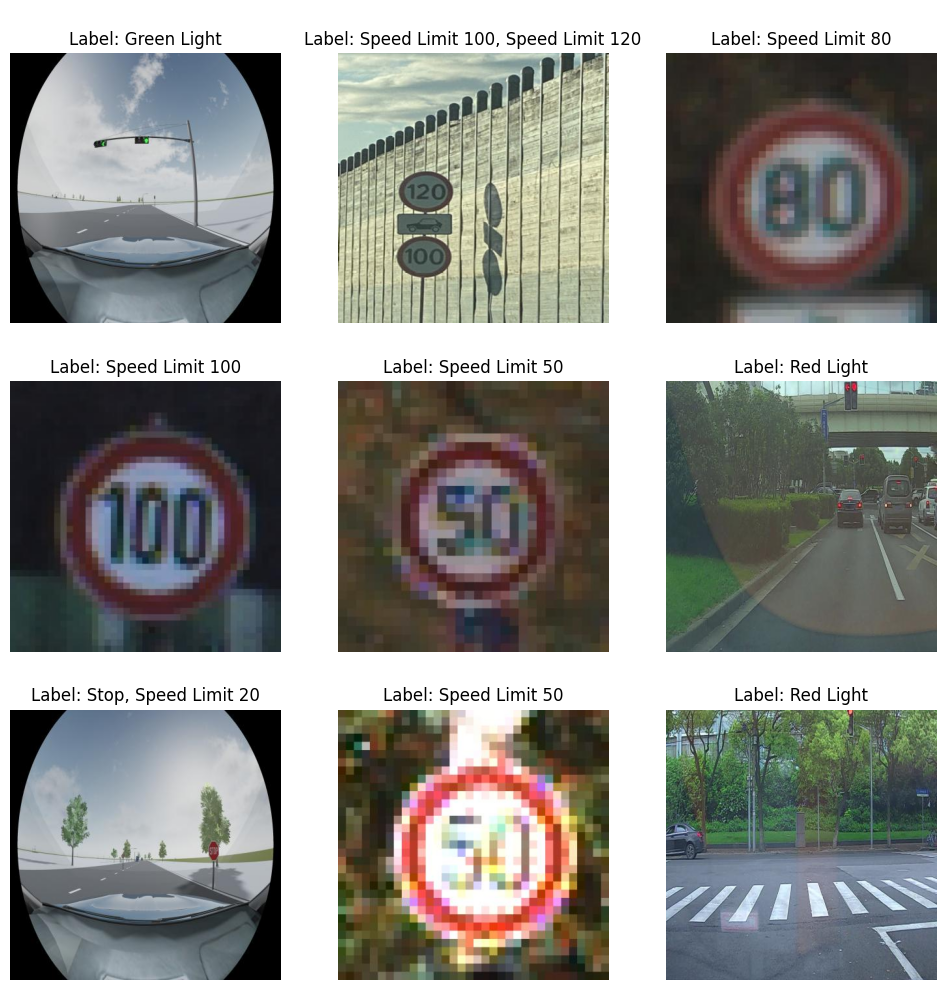

In [11]:
# Visualize multiple train images with labels
samples = random.sample(view_train_img, min(9, len(view_train_img)))
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

for i, img_path in enumerate(samples):
    ax =axes[i]
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.axis("off")

    title = get_labels(img_path)
    ax.set_title(title)

plt.tight_layout()
plt.show()

In [12]:
train_labels_dir = "cardetection_dataset/car/train/labels"
if os.path.exists(train_labels_dir):
    label_files = os.listdir(train_labels_dir)
    print("Contents of 5 random label files:")

    num_samples = min(5, len(label_files))
    random_files = random.sample(label_files, num_samples)

    for file in random_files:
        file_path = os.path.join(train_labels_dir, file)
        print(f"--- {file} ---")
        with open(file_path, 'r') as f:
            print(f.read())
        print()
else:
    print("Directory not found.")

Contents of 5 random label files:
--- 000885_jpg.rf.c971cf62a82be66bb9a3c4df0162c783.txt ---
1 0.6418269230769231 0.0985576923076923 0.02283653846153846 0.09495192307692307
1 0.8100961538461539 0.09254807692307693 0.02283653846153846 0.09615384615384616

--- 001621_JPG_jpg.rf.0d3e48fda6967d6d57a0f4d65ab6bc5a.txt ---
1 0.27524038461538464 0.08413461538461539 0.17908653846153846 0.0985576923076923
0 0.40625 0.5673076923076923 0.046875 0.02403846153846154

--- 00004_00034_00013_png.rf.d686f172b8abbc60eaeb192c379e8fe4.txt ---
11 0.5456730769230769 0.5012019230769231 0.5985576923076923 0.5901442307692307

--- road37_png.rf.26f1c5defb4eb0536ee35d7be8d1fb1c.txt ---
1 0.5180288461538461 0.41225961538461536 0.16706730769230768 0.31009615384615385

--- 000410_jpg.rf.f3c4d482d6d58dbb3007adb19f8c2b67.txt ---
7 0.24759615384615385 0.24639423076923078 0.47596153846153844 0.4891826923076923



In [13]:
import matplotlib.patches as patches

In [14]:
def images_with_bboxes(img_path, ax=None, show_shape=False):
    if ax is None:
        fig, ax = plt.subplots(1)

    img = mpimg.imread(img_path)

    if show_shape:
        print(f"Image Shape: {img.shape} -> (Height, Width, Channels)")

    ax.imshow(img)
    ax.axis("off")

    h, w = img.shape[:2]
    label_path = img_path.replace("/images/", "/labels/").replace(".jpg", ".txt")

    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    class_id = int(parts[0])
                    x_center, y_center, box_w, box_h = map(float, parts[1:])

                    # Convert YOLO format to matplotlib bounding box format (xmin, ymin, width, height)
                    xmin = (x_center - box_w / 2) * w
                    ymin = (y_center - box_h / 2) * h
                    width = box_w * w
                    height = box_h * h

                    class_name = data_info["names"][class_id] if "data_info" in globals() else f"Class {class_id}"

                    # Create and add the bounding box patch
                    rect = patches.Rectangle((xmin, ymin), width, height, linewidth=2, edgecolor='red', facecolor='none')
                    ax.add_patch(rect)

                    # Add class name text
                    ax.text(xmin, ymin - 5, class_name, color='red', fontsize=10, weight='bold',
                            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

Image Shape: (416, 416, 3) -> (Height, Width, Channels)
Image Shape: (416, 416, 3) -> (Height, Width, Channels)
Image Shape: (416, 416, 3) -> (Height, Width, Channels)
Image Shape: (416, 416, 3) -> (Height, Width, Channels)
Image Shape: (416, 416, 3) -> (Height, Width, Channels)
Image Shape: (416, 416, 3) -> (Height, Width, Channels)
Image Shape: (416, 416, 3) -> (Height, Width, Channels)
Image Shape: (416, 416, 3) -> (Height, Width, Channels)
Image Shape: (416, 416, 3) -> (Height, Width, Channels)


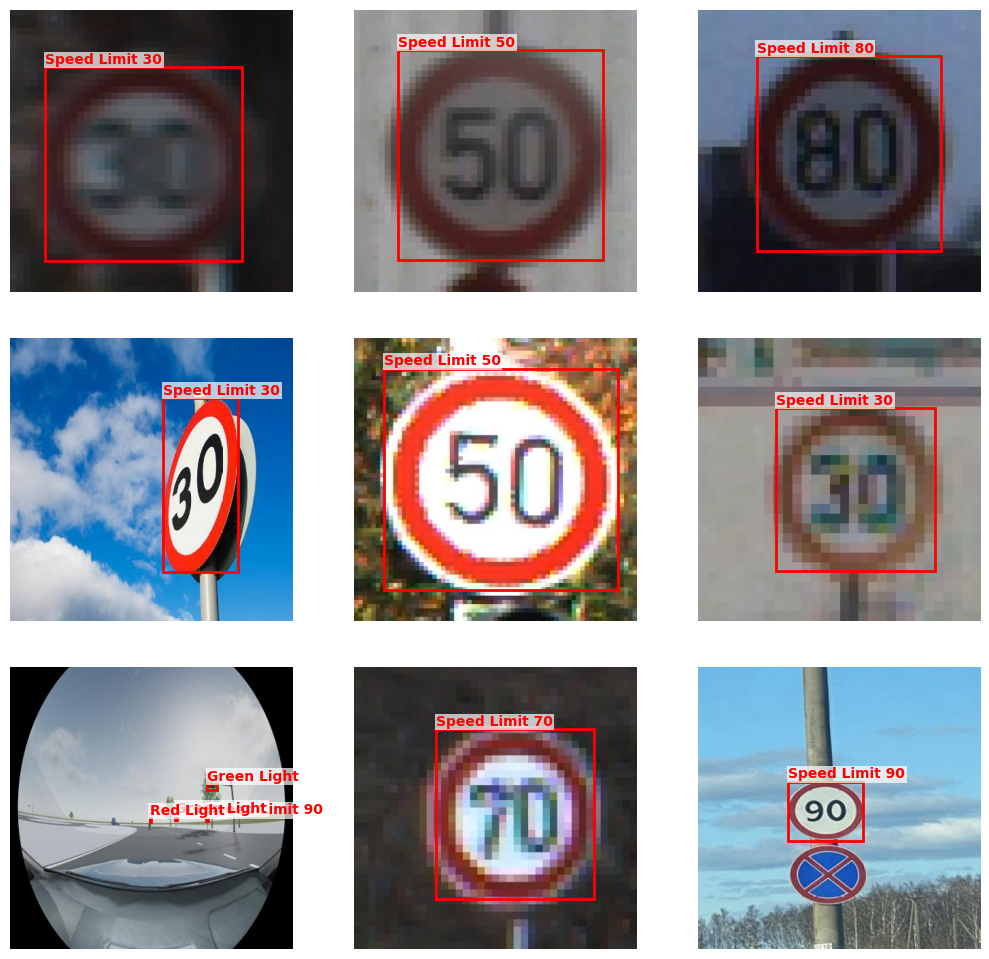

In [15]:
valid_img_paths = glob.glob("cardetection_dataset/car/valid/images/*.jpg")

if valid_img_paths:
    samples = random.sample(valid_img_paths, min(9, len(valid_img_paths)))
    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    axes = axes.flatten()

    for i, img_path in enumerate(samples):
        images_with_bboxes(img_path, ax=axes[i], show_shape=True)

    plt.tight_layout()
    plt.show()
else:
    print("No validation images found.")

##**DATA PREPROCESSING**

In [237]:
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

In [238]:
# Function for applying reproducibility globally
def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    # Ensure deterministic behavior for cuDNN
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [239]:
import cv2
import numpy as np

class TrafficSignDataset(Dataset):
    def __init__(self, img_dir, label_dir, S=7, B=2, C=15, transform=None):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.transform = transform
        self.S = S
        self.B = B
        self.C = C
        self.images = [
            f for f in os.listdir(img_dir)
            if f.endswith(('.jpg', '.png', '.jpeg'))
        ]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        img_file = self.images[index]
        img_path = os.path.join(self.img_dir, img_file)

        # Determine corresponding label file path
        label_file = img_file.rsplit('.', 1)[0] + '.txt'
        label_path = os.path.join(self.label_dir, label_file)

        # Parse bounding boxes
        boxes = []
        class_labels = []
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    data = line.strip().split()
                    if data:
                        class_labels.append(int(data[0]))
                        # YOLO format: [x_center, y_center, width, height]
                        boxes.append([float(x) for x in data[1:5]])

        # Load image using OpenCV (returns BGR) and convert to RGB
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Apply Albumentations transformations
        if self.transform:
            augmentations = self.transform(image=image, bboxes=boxes, class_labels=class_labels)
            image = augmentations['image']
            boxes = augmentations['bboxes']
            class_labels = augmentations['class_labels']

        # Initialize target tensor
        label_matrix = torch.zeros((self.S, self.S, self.C + 5 * self.B))

        for box, class_label in zip(boxes, class_labels):
            class_label = int(class_label)
            x, y, width, height = box

            # Grid Assignment
            i, j = int(self.S * y), int(self.S * x)

            # Coordinate Conversion
            x_cell, y_cell = self.S * x - j, self.S * y - i
            width_cell, height_cell = width * self.S, height * self.S

            # Tensor Population
            if label_matrix[i, j, self.C] == 0:
                # Set objectness score to 1
                label_matrix[i, j, self.C] = 1

                # Assign relative box coordinates
                box_coordinates = torch.tensor(
                    [x_cell, y_cell, width_cell, height_cell]
                )
                label_matrix[i, j, self.C + 1: self.C + 5] = box_coordinates

                # Apply one-hot encoding for the class
                label_matrix[i, j, class_label] = 1

        return image, label_matrix


In [240]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Define execution parameters
GRID_SIZE = 7
BBOXES = 2
CLASSES = len(class_names)
BATCH_SIZE = 32
NUM_WORKERS = 2

# Define Albumentations transformations
train_transform_pipeline = A.Compose([
    A.Resize(height=416, width=416),
    A.ShiftScaleRotate(shift_limit=0.2, scale_limit=0.2, rotate_limit=0, p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
    A.GaussianBlur(blur_limit=(5, 9), sigma_limit=(0.1, 5.), p=0.5),
    A.Normalize(mean=[0.0, 0.0, 0.0], std=[1.0, 1.0, 1.0], max_pixel_value=255.0),
    ToTensorV2(),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

val_transform_pipeline = A.Compose([
    A.Resize(height=416, width=416),
    A.Normalize(mean=[0.0, 0.0, 0.0], std=[1.0, 1.0, 1.0], max_pixel_value=255.0),
    ToTensorV2(),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# Define directory paths
train_img_dir = 'cardetection_dataset/car/train/images'
train_label_dir = 'cardetection_dataset/car/train/labels'
val_img_dir = 'cardetection_dataset/car/valid/images'
val_label_dir = 'cardetection_dataset/car/valid/labels'
test_img_dir = 'cardetection_dataset/car/test/images'
test_label_dir = 'cardetection_dataset/car/test/labels'

# Instantiate datasets
train_dataset = TrafficSignDataset(
    img_dir=train_img_dir,
    label_dir=train_label_dir,
    S=GRID_SIZE, B=BBOXES, C=CLASSES,
    transform=train_transform_pipeline
)

val_dataset = TrafficSignDataset(
    img_dir=val_img_dir,
    label_dir=val_label_dir,
    S=GRID_SIZE, B=BBOXES, C=CLASSES,
    transform=val_transform_pipeline
)

test_dataset = TrafficSignDataset(
    img_dir=test_img_dir,
    label_dir=test_label_dir,
    S=GRID_SIZE, B=BBOXES, C=CLASSES,
    transform=val_transform_pipeline
)

# Initialize DataLoaders
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=True,
    drop_last=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=False,
    drop_last=False
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=False,
    drop_last=False
)


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


##**MODEL BUILDING**

###1. CUSTOM MODEL

In [241]:
import torch.nn as nn

In [242]:
class CNNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, **kwargs):
        super(CNNBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, bias=False, **kwargs)
        self.batchnorm = nn.BatchNorm2d(out_channels)
        self.leakyrelu = nn.LeakyReLU(0.1)

    def forward(self, x):
        return self.leakyrelu(self.batchnorm(self.conv(x)))

class TrafficSignDetector(nn.Module):
    def __init__(self, in_channels=3, S=7, B=2, C=15):
        super(TrafficSignDetector, self).__init__()
        self.S = S
        self.B = B
        self.C = C

        self.features = nn.Sequential(
            CNNBlock(in_channels, 64, kernel_size=7, stride=2, padding=3),
            nn.MaxPool2d(kernel_size=2, stride=2),

            CNNBlock(64, 192, kernel_size=3, padding=1),
            nn.MaxPool2d(kernel_size=2, stride=2),

            CNNBlock(192, 128, kernel_size=1),
            CNNBlock(128, 256, kernel_size=3, padding=1),
            CNNBlock(256, 256, kernel_size=1),
            CNNBlock(256, 512, kernel_size=3, padding=1),
            nn.MaxPool2d(kernel_size=2, stride=2),

            CNNBlock(512, 256, kernel_size=1),
            CNNBlock(256, 512, kernel_size=3, padding=1),
            CNNBlock(512, 256, kernel_size=1),
            CNNBlock(256, 512, kernel_size=3, padding=1),
            CNNBlock(512, 256, kernel_size=1),
            CNNBlock(256, 512, kernel_size=3, padding=1),
            CNNBlock(512, 256, kernel_size=1),
            CNNBlock(256, 512, kernel_size=3, padding=1),
            CNNBlock(512, 512, kernel_size=1),
            CNNBlock(512, 1024, kernel_size=3, padding=1),
            nn.MaxPool2d(kernel_size=2, stride=2),

            CNNBlock(1024, 512, kernel_size=1),
            CNNBlock(512, 1024, kernel_size=3, padding=1),
            CNNBlock(1024, 512, kernel_size=1),
            CNNBlock(512, 1024, kernel_size=3, padding=1),

            CNNBlock(1024, 1024, kernel_size=3, padding=1),
            CNNBlock(1024, 1024, kernel_size=3, stride=2, padding=1),
            CNNBlock(1024, 1024, kernel_size=3, padding=1),
            CNNBlock(1024, 1024, kernel_size=3, padding=1)
        )

        # Fully convolutional head to replace linear layers
        self.head = nn.Conv2d(1024, self.C + self.B * 5, kernel_size=1)

    def forward(self, x):
        x = self.features(x)
        x = self.head(x)

        # Reshape to match DataLoader target tensor format
        # Permute from (Batch, Channels, S, S) to (Batch, S, S, Channels)
        x = x.permute(0, 2, 3, 1)
        return x


In [243]:
model = TrafficSignDetector(in_channels=3, S=GRID_SIZE, B=BBOXES, C=CLASSES)

In [72]:
!pip install torchinfo

In [244]:
# Get model summary
import torchinfo

torchinfo.summary(model=model)

Layer (type:depth-idx)                   Param #
TrafficSignDetector                      --
├─Sequential: 1-1                        --
│    └─CNNBlock: 2-1                     --
│    │    └─Conv2d: 3-1                  9,408
│    │    └─BatchNorm2d: 3-2             128
│    │    └─LeakyReLU: 3-3               --
│    └─MaxPool2d: 2-2                    --
│    └─CNNBlock: 2-3                     --
│    │    └─Conv2d: 3-4                  110,592
│    │    └─BatchNorm2d: 3-5             384
│    │    └─LeakyReLU: 3-6               --
│    └─MaxPool2d: 2-4                    --
│    └─CNNBlock: 2-5                     --
│    │    └─Conv2d: 3-7                  24,576
│    │    └─BatchNorm2d: 3-8             256
│    │    └─LeakyReLU: 3-9               --
│    └─CNNBlock: 2-6                     --
│    │    └─Conv2d: 3-10                 294,912
│    │    └─BatchNorm2d: 3-11            512
│    │    └─LeakyReLU: 3-12              --
│    └─CNNBlock: 2-7                     --
│    │

###2. ULTRALYTICS MODELLING

In [25]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 74.7 MB/s eta 0:00:00


In [261]:
from IPython.display import Image, display
from ultralytics import YOLO

In [262]:
# Initialize the YOLOv8 Nano architecture
model_ultralytics = YOLO('yolov8n.pt')

In [245]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

##**MODEL TRAINING**

###1. CUSTOM MODEL TRAINING

In [246]:
import torch.optim as optim
from torchvision.ops import box_iou, box_convert

In [247]:
def intersection_over_union(boxes_preds, boxes_labels, box_format="midpoint"):
    """
    Calculates intersection over union element-wise to avoid large N x N memory allocations.
    """
    if box_format == "midpoint":
        box1_x1 = boxes_preds[..., 0:1] - boxes_preds[..., 2:3] / 2
        box1_y1 = boxes_preds[..., 1:2] - boxes_preds[..., 3:4] / 2
        box1_x2 = boxes_preds[..., 0:1] + boxes_preds[..., 2:3] / 2
        box1_y2 = boxes_preds[..., 1:2] + boxes_preds[..., 3:4] / 2

        box2_x1 = boxes_labels[..., 0:1] - boxes_labels[..., 2:3] / 2
        box2_y1 = boxes_labels[..., 1:2] - boxes_labels[..., 3:4] / 2
        box2_x2 = boxes_labels[..., 0:1] + boxes_labels[..., 2:3] / 2
        box2_y2 = boxes_labels[..., 1:2] + boxes_labels[..., 3:4] / 2

    x1 = torch.max(box1_x1, box2_x1)
    y1 = torch.max(box1_y1, box2_y1)
    x2 = torch.min(box1_x2, box2_x2)
    y2 = torch.min(box1_y2, box2_y2)

    # .clamp(0) is for the case when they do not intersect
    intersection = (x2 - x1).clamp(0) * (y2 - y1).clamp(0)

    box1_area = abs((box1_x2 - box1_x1) * (box1_y2 - box1_y1))
    box2_area = abs((box2_x2 - box2_x1) * (box2_y2 - box2_y1))

    return intersection / (box1_area + box2_area - intersection + 1e-6)

class CustomLoss(nn.Module):
    def __init__(self, S=7, B=2, C=15):
        super(CustomLoss, self).__init__()
        self.mse = nn.MSELoss(reduction="sum")
        self.S = S
        self.B = B
        self.C = C
        self.lambda_noobj = 0.5
        self.lambda_coord = 5

    def forward(self, predictions, target):
        predictions = predictions.reshape(-1, self.S, self.S, self.C + self.B * 5)
        target = target.reshape(-1, self.S, self.S, self.C + self.B * 5)

        # Extract bounding boxes for both predictions
        box1_preds = predictions[..., self.C+1 : self.C+5]
        box2_preds = predictions[..., self.C+6 : self.C+10]

        target_boxes = target[..., self.C+1 : self.C+5]

        # Use custom element-wise IoU instead of torchvision's pairwise box_iou
        iou_b1 = intersection_over_union(box1_preds, target_boxes, box_format="midpoint")
        iou_b2 = intersection_over_union(box2_preds, target_boxes, box_format="midpoint")

        ious = torch.cat([iou_b1.unsqueeze(0), iou_b2.unsqueeze(0)], dim=0)
        iou_maxes, bestbox = torch.max(ious, dim=0)

        exists_box = target[..., self.C].unsqueeze(3)

        # For box coordinates
        box_predictions = exists_box * (
            (
                bestbox * predictions[..., self.C+6 : self.C+10]
                + (1 - bestbox) * predictions[..., self.C+1 : self.C+5]
            )
        )
        box_targets = exists_box * target_boxes

        # We add 1e-6 to prevent gradient explosion at derivative of sqrt(0)
        box_predictions[..., 2:4] = torch.sign(box_predictions[..., 2:4]) * torch.sqrt(
            torch.abs(box_predictions[..., 2:4] + 1e-6)
        )
        box_targets[..., 2:4] = torch.sqrt(box_targets[..., 2:4])

        box_loss = self.mse(
            torch.flatten(box_predictions, end_dim=-2),
            torch.flatten(box_targets, end_dim=-2)
        )

        # Object detected loss
        pred_box = (
            bestbox * predictions[..., self.C+5 : self.C+6]
            + (1 - bestbox) * predictions[..., self.C : self.C+1]
        )
        object_loss = self.mse(
            torch.flatten(exists_box * pred_box),
            torch.flatten(exists_box * target[..., self.C : self.C+1])
        )

        # No object detected loss
        no_object_loss = self.mse(
            torch.flatten((1 - exists_box) * predictions[..., self.C : self.C+1], start_dim=1),
            torch.flatten((1 - exists_box) * target[..., self.C : self.C+1], start_dim=1)
        )
        no_object_loss += self.mse(
            torch.flatten((1 - exists_box) * predictions[..., self.C+5 : self.C+6], start_dim=1),
            torch.flatten((1 - exists_box) * target[..., self.C : self.C+1], start_dim=1)
        )

        # Classification loss
        class_loss = self.mse(
            torch.flatten(exists_box * predictions[..., :self.C], end_dim=-2),
            torch.flatten(exists_box * target[..., :self.C], end_dim=-2)
        )

        # Total loss
        loss = (
            self.lambda_coord * box_loss
            + object_loss
            + self.lambda_noobj * no_object_loss
            + class_loss
        )

        return loss / predictions.shape[0]

custom_loss_module = CustomLoss(S=GRID_SIZE, B=BBOXES, C=CLASSES)

def custom_loss(predictions, targets):
    return custom_loss_module(predictions, targets)

optimizer = optim.Adam(params=model.parameters(), lr=0.001)


In [248]:
from tqdm import tqdm
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [249]:
from PIL import Image

LEARNING_RATE = 1e-4
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4) # weight decay for regularization to prevent overfitting
# Learning rate scheduler
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

model.to(device)

# Initialize GradScaler for Mixed Precision Training
scaler = torch.cuda.amp.GradScaler()

def train_fn(train_loader, model, optimizer, loss_fn):
    loop = tqdm(train_loader, leave=True)
    mean_loss = []

    for batch_idx, (x, y) in enumerate(loop):
        x, y = x.to(device), y.to(device)

        # Use Automatic Mixed Precision to save memory
        with torch.cuda.amp.autocast():
            out = model(x)
            loss = loss_fn(out, y)

        mean_loss.append(loss.item())
        optimizer.zero_grad()

        # Backward pass with scaled loss
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # update progress bar
        loop.set_postfix(loss=loss.item())

    return sum(mean_loss) / len(mean_loss)

def val_fn(val_loader, model, loss_fn):
    loop = tqdm(val_loader, leave=True)
    mean_loss = []

    with torch.inference_mode():
        for batch_idx, (x, y) in enumerate(loop):
            x, y = x.to(device), y.to(device)

            with torch.cuda.amp.autocast():
                out = model(x)
                loss = loss_fn(out, y)

            mean_loss.append(loss.item())
            loop.set_postfix(val_loss=loss.item())

    return sum(mean_loss) / len(mean_loss)

epochs = 100
epoch_count = []
loss_values = []
val_loss_values = []

# Empty CUDA cache to free up unallocated memory before training
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(f"Starting training on {device}...")
for epoch in range(epochs):
    print(f"\nEpoch: {epoch+1}/{epochs}")

    # Training Phase
    model.train()
    avg_loss = train_fn(train_loader, model, optimizer, custom_loss)

    # Validation Phase
    model.eval()
    avg_val_loss = val_fn(val_loader, model, custom_loss)

    # Step the scheduler based on the validation loss
    scheduler.step(avg_val_loss)

    epoch_count.append(epoch + 1)
    loss_values.append(avg_loss)
    val_loss_values.append(avg_val_loss)

    print(f"Epoch {epoch+1} Train Loss: {avg_loss:.4f} | Val Loss: {avg_val_loss:.4f}")


/tmp/ipykernel_512/3236503394.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Starting training on cuda...

Epoch: 1/100


  0%|          | 0/110 [00:00<?, ?it/s]/tmp/ipykernel_512/3236503394.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
  0%|          | 0/26 [00:00<?, ?it/s]/tmp/ipykernel_512/3236503394.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 26/26 [00:02<00:00, 10.61it/s, val_loss=1.89]


Epoch 1 Train Loss: 13.0303 | Val Loss: 3.1862

Epoch: 2/100


100%|██████████| 26/26 [00:02<00:00, 10.70it/s, val_loss=1.48]


...

Epoch 98 Train Loss: 0.1661 | Val Loss: 0.3293

Epoch: 99/100


100%|██████████| 26/26 [00:02<00:00, 10.78it/s, val_loss=0.0439]


Epoch 99 Train Loss: 0.1654 | Val Loss: 0.3237

Epoch: 100/100


100%|██████████| 26/26 [00:02<00:00, 10.66it/s, val_loss=0.0269]

Epoch 100 Train Loss: 0.1619 | Val Loss: 0.3368


###2. YOLOv8 MODEL TRAINING

In [263]:
# Define the absolute or relative path to the dataset configuration file
yaml_path = 'cardetection_dataset/car/data.yaml'

# Execute the training sequence
results = model_ultralytics.train(
    data=yaml_path,
    epochs=20,
    imgsz=416,
    batch=16,
    device=device, # Designates GPU execution
    project='yolov8_traffic_signs',
    name='train_run'
)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=cardetection_dataset/car/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train_run, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=

##**MODEL TESTING**

In [250]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [251]:
# Gather predicted and actual values
def get_predictions(model, dataloader, device, conf_threshold=0.2, S=GRID_SIZE, B=BBOXES, C=CLASSES):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.inference_mode():
        for images, targets in dataloader:
            images = images.to(device)
            targets = targets.to(device)

            logits = model(images)
            batch_size = logits.shape[0]

            # Reshape predictions and targets
            predictions = logits.reshape(-1, S, S, C + B * 5)
            targets = targets.reshape(-1, S, S, C + B * 5)

            for b in range(batch_size):
                pred = predictions[b]

                # Get classes, confidences, and boxes
                pred_classes = torch.argmax(pred[..., :C], dim=-1)

                # Extract boxes and confidences
                conf1 = pred[..., C:C+1]
                box1 = pred[..., C+1:C+5]
                conf2 = pred[..., C+5:C+6]
                box2 = pred[..., C+6:C+10]

                # Choose the box with the highest confidence for each grid cell
                conf_mask = conf1 > conf2
                best_conf = torch.where(conf_mask, conf1, conf2).squeeze(-1)
                best_box = torch.where(conf_mask.expand_as(box1), box1, box2)

                # Filter by confidence threshold
                mask = best_conf > conf_threshold

                filtered_boxes = best_box[mask]
                filtered_scores = best_conf[mask]
                filtered_classes = pred_classes[mask]

                if filtered_boxes.shape[0] > 0:
                    pred_boxes_xyxy = box_convert(filtered_boxes, in_fmt='cxcywh', out_fmt='xyxy')
                else:
                    pred_boxes_xyxy = torch.empty((0, 4), device=device)

                all_preds.append({
                    'boxes': pred_boxes_xyxy,
                    'scores': filtered_scores,
                    'labels': filtered_classes
                })

                target = targets[b]

                target_conf = target[..., C]
                target_classes = torch.argmax(target[..., :C], dim=-1)
                target_boxes = target[..., C+1:C+5]

                obj_mask = target_conf == 1

                t_boxes = target_boxes[obj_mask]
                t_labels = target_classes[obj_mask]

                if t_boxes.shape[0] > 0:
                    target_boxes_xyxy = box_convert(t_boxes, in_fmt='cxcywh', out_fmt='xyxy')
                else:
                    target_boxes_xyxy = torch.empty((0, 4), device=device)

                all_targets.append({
                    'boxes': target_boxes_xyxy,
                    'labels': t_labels
                })

    return all_preds, all_targets


In [252]:
train_labels, train_preds = get_predictions(model, train_loader, device)
test_labels, test_preds = get_predictions(model, test_loader, device)

##**MODEL EVALUATION**

###1. CUSTOM MODEL EVALUATION

In [145]:
!pip install -q torchmetrics

In [253]:
from sklearn.metrics import f1_score
from torchmetrics.detection.mean_ap import MeanAveragePrecision

In [254]:
def evaluate_model(model, dataloader, device):
    print("Evaluating model...")
    map_metric = MeanAveragePrecision(box_format='xyxy', iou_type='bbox')

    # Get predictions and targets in the format expected by torchmetrics
    preds, targets = get_predictions(model, dataloader, device)

    map_metric.update(preds, targets)
    map_results = map_metric.compute()

    print(f"mAP (IoU=0.50:0.95): {map_results['map']:.4f}")
    print(f"mAP (IoU=0.50): {map_results['map_50']:.4f}")
    print(f"mAP (IoU=0.75): {map_results['map_75']:.4f}")

    return map_results['map']

test_map = evaluate_model(model, test_loader, device)

Evaluating model...
mAP (IoU=0.50:0.95): 0.4749
mAP (IoU=0.50): 0.6455
mAP (IoU=0.75): 0.5166


###2. YOLOv8 MODEL EVALUATION

In [260]:
# Execute validation on the test subset
metrics = model_ultralytics.val(
    split='test',
    project='yolov8_traffic_signs',
    name='val_run'
)

# Output exact Mean Average Precision metrics
print("Quantitative Metrics (Test Set):")
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"mAP50:    {metrics.box.map50:.4f}")
print(f"mAP75:    {metrics.box.map75:.4f}")

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

WARNING ⚠️ Dataset 'coco.yaml' images not found, missing path '/content/datasets/coco/val2017.txt'
Unzipping /content/datasets/coco2017labels-segments.zip to /content/datasets/coco...: 100% ━━━━━━━━━━━━ 122232/122232 4.6Kfiles/s 26.4s

KeyboardInterrupt: 

##**EXPERIMENTS FOR THE CUSTOM MODEL**

In [255]:
import pandas as pd
from IPython.display import display

# Initialize the experiments data with placeholders for you to fill
experiments_data = {
    "Experiment Number": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
    "Experiment Description": [
        "(1)Initial Baseline",
        "Change GRID_SIZE to 13 with 832x832 image resize",
        "-------",
        "Added ColorJitter and GaussianBlur augmentation",
        "Final Baseline",
        "Increased batch size to 16",
        "Increased batch size to 32",
        "Increased batch size to 64",
        "Increased epoch to 100",
        "32 batch size and 100 epoch",
        "Reduced the number of convolutional layers",
        "24 convolutional layers and completely removed the linear layers",
        "Changed the learning rate to 2e-5",
        "Added ColorJitter, GaussianBlur, and random scaling augmentations"
    ],
    "GRID_SIZE": [
        7, # Baseline score from previous evaluation
        13,
        None,
        7,
        7,
        7,
        7,
        7,
        7,
        7,
        7,
        7,
        7,
        7
    ],
    "IMAGE SHAPE": [
        "416x416", # Baseline score from previous evaluation
        "832x832",
        "------",
        "416x416",
        "416x416",
        "416x416",
        "416x416",
        "416x416",
        "416x416",
        "416x416",
        "416x416",
        "416x416",
        "416x416",
        "416x416"
    ],
    "EPOCH": [
        100, # Baseline score from previous evaluation
        100,
        None,
        50,
        50,
        50,
        50,
        50,
        100,
        100,
        100,
        100,
        100,
        100
    ],
    "BATCH_SIZE": [
        8, # Baseline score from previous evaluation
        8,
        None,
        8,
        8,
        16,
        32,
        64,
        64,
        32,
        32,
        32,
        32,
        32
    ],
    "LEARNING_RATE": [
        0.0001, # Baseline score from previous evaluation
        0.0001,
        None,
        0.0001,
        0.0001,
        0.0001,
        0.0001,
        0.0001,
        0.0001,
        0.0001,
        0.0001,
        0.0001,
        0.00002,
        0.0001
    ],
    "# of Parameters": [
        "60,194,777", # Baseline score from previous evaluation
        "60,194,777",
        "----",
        "85,665,769",
        "85,665,769",
        "85,665,769",
        "85,665,769",
        "85,665,769",
        "85,665,769",
        "85,665,769",
        "21,070,025",
        "60,194,777",
        "60,194,777",
        "60,194,777"
    ],
    "Evaluation Score (mAP)": [
        0.4448, # Baseline score from previous evaluation
        0.4261,
        None,
        0.3018,
        0.2869,
        0.2872,
        0.2812,
        0.2675,
        0.2762,
        0.2946,
        0.2946,
        0.4129,
        0.2910,
        0.4749
    ]
}

# Create a pandas DataFrame
experiments_df = pd.DataFrame(experiments_data)

# Display the experiments table
display(experiments_df)

,Experiment Number,Experiment Description,GRID_SIZE,IMAGE SHAPE,EPOCH,BATCH_SIZE,LEARNING_RATE,# of Parameters,Evaluation Score (mAP)
0,1,(1)Initial Baseline,7.0,416x416,100.0,8.0,0.00010,"60,194,777",0.4448
1,2,Change GRID_SIZE to 13 with 832x832 image resize,13.0,832x832,100.0,8.0,0.00010,"60,194,777",0.4261
2,3,-------,NaN,------,NaN,NaN,NaN,----,NaN
3,4,Added ColorJitter and GaussianBlur augmentation,7.0,416x416,50.0,8.0,0.00010,"85,665,769",0.3018
4,5,Final Baseline,7.0,416x416,50.0,8.0,0.00010,"85,665,769",0.2869
5,6,Increased batch size to 16,7.0,416x416,50.0,16.0,0.00010,"85,665,769",0.2872
6,7,Increased batch size to 32,7.0,416x416,50.0,32.0,0.00010,"85,665,769",0.2812
7,8,Increased batch size to 64,7.0,416x416,50.0,64.0,0.00010,"85,665,769",0.2675
8,9,Increased epoch to 100,7.0,416x416,100.0,64.0,0.00010,"85,665,769",0.2762
9,10,32 batch size and 100 epoch,7.0,416x416,100.0,32.0,0.00010,"85,665,769",0.2946


##**VISUALIZATION OF RESULTS**

In [256]:
from sklearn.metrics import confusion_matrix

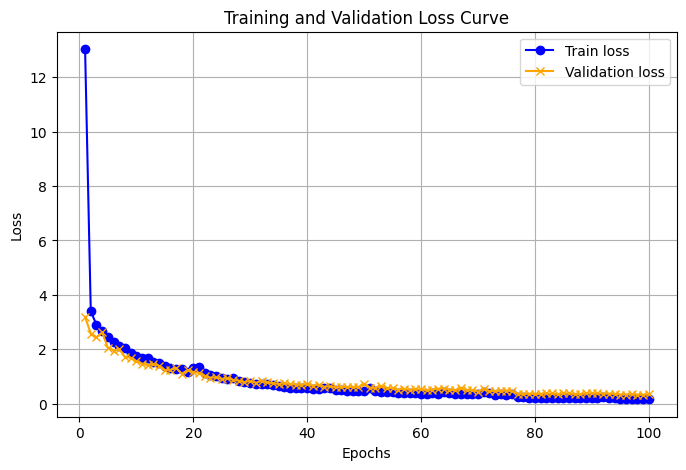

In [257]:
plt.figure(figsize=(8, 5))
plt.plot(epoch_count, loss_values, label="Train loss", color="blue", marker="o")
plt.plot(epoch_count, val_loss_values, label="Validation loss", color="orange", marker="x")
plt.title("Training and Validation Loss Curve")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.grid(True)
plt.legend()
plt.show()

In [258]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
from torchvision.ops import box_iou
import numpy as np

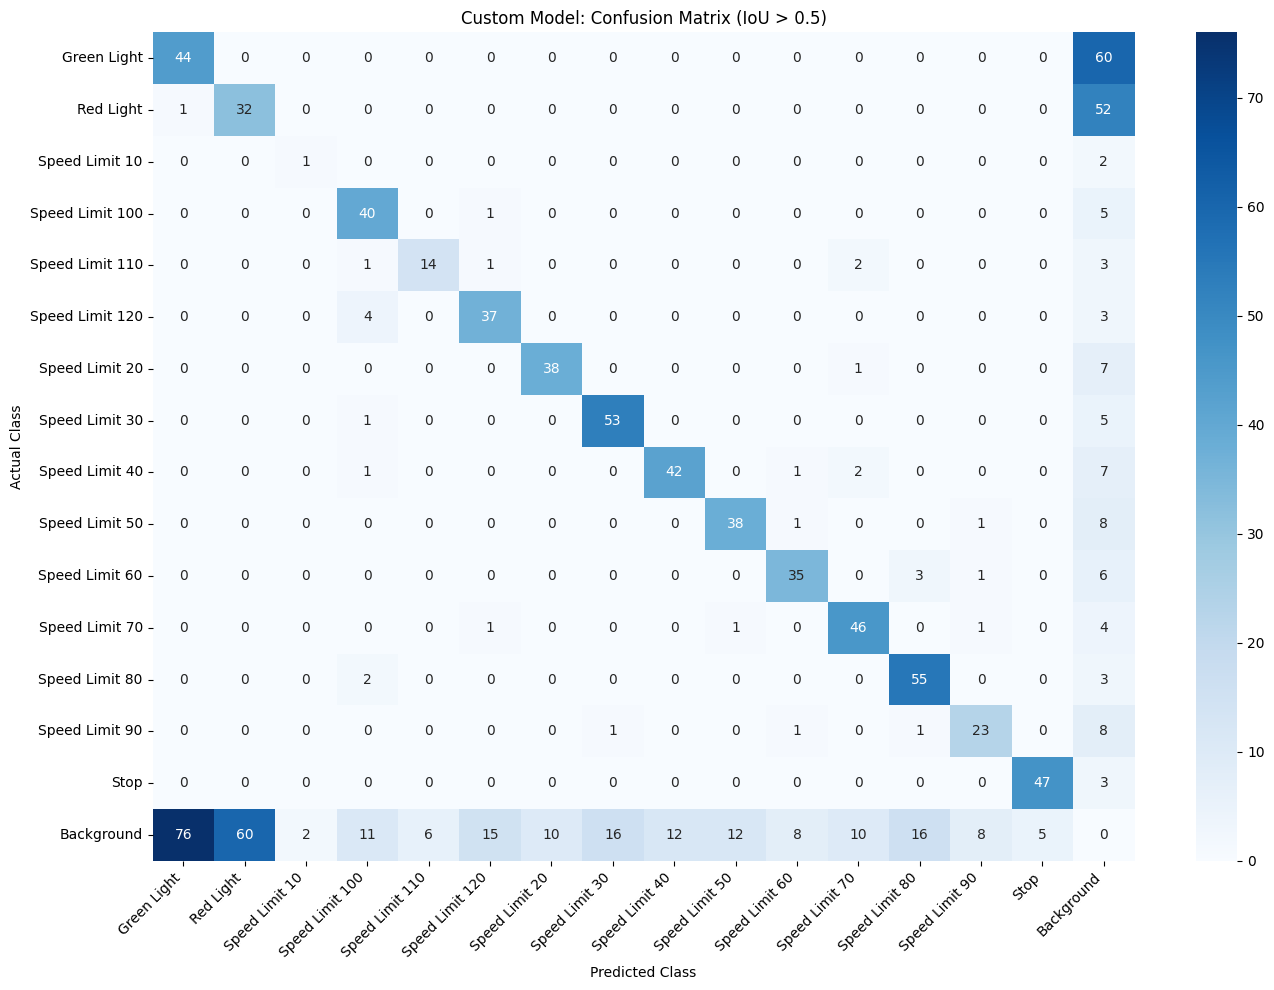

In [259]:
# Get predictions from the test set for the CUSTOM MODEL
preds, targets = get_predictions(model, test_loader, device)

y_true = []
y_pred = []
background_class = 15  # Use class ID 15 for Background

# Match predictions to ground truth targets to build the confusion matrix lists
for i in range(len(targets)):
    t_boxes = targets[i]['boxes']
    t_labels = targets[i]['labels']
    p_boxes = preds[i]['boxes']
    p_labels = preds[i]['labels']

    if len(t_boxes) == 0 and len(p_boxes) == 0:
        continue
    elif len(t_boxes) == 0:
        # All predictions are False Positives (Background truth)
        y_pred.extend(p_labels.cpu().numpy())
        y_true.extend([background_class] * len(p_boxes))
        continue
    elif len(p_boxes) == 0:
        # All targets are False Negatives (Background predicted)
        y_true.extend(t_labels.cpu().numpy())
        y_pred.extend([background_class] * len(t_boxes))
        continue

    # Compute IoU between target and predicted boxes
    ious = box_iou(t_boxes, p_boxes)  # Shape: (N_t, N_p)

    matched_preds = set()
    for t_idx, t_label in enumerate(t_labels):
        best_iou, p_idx = ious[t_idx].max(dim=0)
        if best_iou > 0.5:
            # True Positive or Misclassification
            y_true.append(t_label.item())
            y_pred.append(p_labels[p_idx].item())
            matched_preds.add(p_idx.item())
        else:
            # False Negative (Missed object)
            y_true.append(t_label.item())
            y_pred.append(background_class)

    # Any predictions not matched to a target are False Positives
    for p_idx, p_label in enumerate(p_labels):
        if p_idx not in matched_preds:
            y_pred.append(p_label.item())
            y_true.append(background_class)

# Extend class names with the Background class
ext_class_names = class_names + ["Background"]

# Calculate confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=range(num_classes + 1))

# Plot the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=ext_class_names, yticklabels=ext_class_names)
plt.title('Custom Model: Confusion Matrix (IoU > 0.5)')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
import os
from IPython.display import Image, display

# Paths match the project/name parameters used in the validation cell
val_dir = 'yolov8_traffic_signs/val_run'

# YOLOv8 generates both normalized and absolute confusion matrices
confusion_matrix_path = f'{val_dir}/confusion_matrix_normalized.png'
fallback_cm_path = f'{val_dir}/confusion_matrix.png'

print("Ultralytics YOLOv8 Model: Confusion Matrix Heatmap")
if os.path.exists(confusion_matrix_path):
    display(Image(filename=confusion_matrix_path, width=900))
elif os.path.exists(fallback_cm_path):
    display(Image(filename=fallback_cm_path, width=900))
else:
    print(f"File not found. Make sure the YOLOv8 validation step ran successfully.")

In [ ]:
def plot_predicted_image(img_path, model, device, transform, conf_threshold=0.2, S=GRID_SIZE, B=BBOXES, C=CLASSES):
    img = Image.open(img_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.inference_mode():
        logits = model(img_tensor)

    pred = logits.reshape(-1, S, S, C + B * 5)[0]

    pred_classes = torch.argmax(pred[..., :C], dim=-1)
    conf1 = pred[..., C:C+1]
    box1 = pred[..., C+1:C+5]
    conf2 = pred[..., C+5:C+6]
    box2 = pred[..., C+6:C+10]

    conf_mask = conf1 > conf2
    best_conf = torch.where(conf_mask, conf1, conf2).squeeze(-1)
    best_box = torch.where(conf_mask.expand_as(box1), box1, box2)

    mask = best_conf > conf_threshold
    filtered_boxes = best_box[mask]
    filtered_classes = pred_classes[mask]
    filtered_scores = best_conf[mask]

    # Get cell indices where objects were detected
    indices = mask.nonzero(as_tuple=False)

    fig, ax = plt.subplots(1, figsize=(8, 8))
    # Resize image to model input size for plotting
    img_np = np.array(img.resize((448, 448)))  # Updated to match the potential 448x448 resize
    ax.imshow(img_np)
    ax.axis("off")

    for idx, box, cls, score in zip(indices, filtered_boxes, filtered_classes, filtered_scores):
        i, j = idx[0].item(), idx[1].item()  # i is row (y), j is col (x)

        # Box coordinates are relative to the grid cell
        x_cell, y_cell, w_cell, h_cell = box.tolist()

        # Convert to global relative coordinates [0, 1]
        x_global = (j + x_cell) / S
        y_global = (i + y_cell) / S
        w_global = w_cell / S
        h_global = h_cell / S

        # Convert to pixel coordinates for the resized image
        w = w_global * 448
        h = h_global * 448
        x = x_global * 448 - w / 2
        y = y_global * 448 - h / 2

        class_name = class_names[cls.item()]

        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        ax.text(x, y - 5, f"{class_name} ({score:.2f})", color='red', fontsize=10, weight='bold',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

    plt.title("Model Prediction on Random Test Image")
    plt.tight_layout()
    plt.show()


In [ ]:
from PIL import Image
import glob
import random

test_images = glob.glob("cardetection_dataset/car/test/images/*.jpg")
if test_images:
    random_test_img = random.choice(test_images)
    plot_predicted_image(random_test_img, model, device, transform_pipeline)
else:
    print("No test images found.")

In [ ]:
import glob
from IPython.display import Image, display

# Retrieve sample images from the test directory
test_dir = 'cardetection_dataset/car/test/images/*.jpg'
sample_images = glob.glob(test_dir)[:5]

# Execute inference and save spatial predictions
predict_results = model_ultralytics.predict(
    source=sample_images,
    conf=0.25,
    save=True,
    project='yolov8_traffic_signs',
    name='predict_run'
)

# Display the annotated output images
# Use the save_dir from the first result to get the correct output folder
predicted_images_dir = predict_results[0].save_dir
predicted_images = glob.glob(f'{predicted_images_dir}/*.jpg')

print("Visual Inference Samples:")
for img_path in predicted_images:
    display(Image(filename=img_path, width=600))